In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("Ukraine_flats_ML.csv")

df = df.drop(columns=["lat", "lon"])

print(df.shape)
print("Пропусків:", df.isna().sum().sum())

(10172, 86)
Пропусків: 0


In [3]:
CAT_PREFIX = "city_"
CAT_COL = "city_raw"
UKRAINE_CITIES = [
    "Lviv", "Kharkiv", "Dnipro", "Zaporizhzhia", "Odesa", "Poltava", "Mykolaiv",
    "Cherkasy", "Kropyvnytskyi", "Sumy", "Chernihiv", "Zhytomyr", "Lutsk",
    "Ivano-Frankivsk", "Ternopil", "Khmelnytskyi", "Uzhhorod", "Vinnytsia",
    "Rivne", "Chernivtsi", "Kherson",
]


def reconstruct_categorical(df: pd.DataFrame, prefix: str, master_list: list[str]) -> tuple[pd.Series, list[str]]:
    dummy_cols = [c for c in df.columns if c.startswith(prefix)]
    present = {c[len(prefix):] for c in dummy_cols}
    missing_sorted = sorted(m for m in master_list if m not in present)
    reference = missing_sorted[0]

    cat = pd.Series(reference, index=df.index, dtype="object")
    for c in dummy_cols:
        name = c[len(prefix):]
        cat = cat.where(~df[c].astype(bool), name)
    return cat, dummy_cols


df[CAT_COL], _dummy_cols = reconstruct_categorical(df, CAT_PREFIX, UKRAINE_CITIES)
df = df.drop(columns=_dummy_cols)
print(df[CAT_COL].value_counts())

city_raw
Odesa              2518
Kharkiv            1997
Lviv               1580
Dnipro             1352
Ivano-Frankivsk     812
Zaporizhzhia        431
Mykolaiv            392
Poltava             287
Khmelnytskyi        215
Ternopil            112
Vinnytsia            99
Rivne                73
Lutsk                68
Chernihiv            45
Sumy                 43
Uzhhorod             38
Zhytomyr             35
Kropyvnytskyi        31
Cherkasy             22
Chernivtsi           12
Kherson              10
Name: count, dtype: int64


In [4]:
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
if len(nan_counts) > 0:
    fully_empty = nan_counts[nan_counts == len(df)].index.tolist()
    if fully_empty:
        print("Повністю порожні колонки (медіану порахувати нема з чого — дропаємо):")
        print(fully_empty)
        df = df.drop(columns=fully_empty)
        nan_counts = nan_counts.drop(index=fully_empty)

    if len(nan_counts) > 0:
        print("УВАГА: часткові пропуски після препроцесингу — заповнюємо медіаною:")
        print(nan_counts)
        df = df.fillna(df.median(numeric_only=True))
else:
    print("Пропусків немає.")

Пропусків немає.


In [5]:
TARGET = "price"


def build_feature_frame(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c not in (TARGET, CAT_COL)]
    X = df[feature_cols].astype({c: "float64" for c in df[feature_cols].select_dtypes("bool").columns})
    y = np.log1p(df[TARGET].astype(float))
    return X, y, df[CAT_COL]

In [6]:
def fit_target_encoding(cat_train: pd.Series, y_train: pd.Series, m: float = 10.0):
    global_mean = float(y_train.mean())
    stats = y_train.groupby(cat_train).agg(["mean", "count"])
    mapping = (stats["count"] * stats["mean"] + m * global_mean) / (stats["count"] + m)
    return mapping, global_mean


def apply_target_encoding(cat: pd.Series, mapping: pd.Series, global_mean: float) -> pd.Series:
    return cat.map(mapping).fillna(global_mean)

In [7]:
def drop_constant_columns(X: pd.DataFrame) -> pd.DataFrame:
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if constant_cols:
        print(f"  Прибрано {len(constant_cols)} константних колонок: {constant_cols}")
    return X.drop(columns=constant_cols)


def prune_by_vif(X: pd.DataFrame, thresh: float = 10.0) -> list[str]:
    X = drop_constant_columns(X).astype(float)
    X_const = add_constant(X, has_constant="add")

    while X_const.shape[1] > 2:
        vifs = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns,
        ).drop("const")
        worst = vifs.idxmax()
        if vifs[worst] < thresh:
            break
        print(f"  Дропаю '{worst}' (VIF={vifs[worst]:.1f})")
        X_const = X_const.drop(columns=[worst])

    kept = [c for c in X_const.columns if c != "const"]
    print(f"  Лишилось {len(kept)} ознак після VIF-відбору")
    return kept


def evaluate(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> dict:
    """Ціль — log(price), де price вже $/м². MAPE/MAE/RMSE рахуються на
    відновленому $/м² (не на загальній ціні об'єкта — тут її й нема,
    оскільки area вже не бере участі в цілі)."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "MAE_$/m2": mean_absolute_error(y_true, y_pred),
        "RMSE_$/m2": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_%": (np.abs((y_true - y_pred) / y_true).mean()) * 100,
    }


RF_GRID = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 12, 20],
    "min_samples_leaf": [1, 2, 4],
}
HGB_GRID = {
    "max_iter": [200, 400, 600],
    "max_depth": [None, 4, 8],
    "learning_rate": [0.03, 0.06, 0.1],
}


def fit_variant(model_name, X_train, X_test, y_train, y_test, cols, fixed_params=None):
    X_train_c, X_test_c = X_train[cols], X_test[cols]

    if model_name == "Ridge":
        scaler = StandardScaler()
        Xs_train_c = scaler.fit_transform(X_train_c)
        Xs_test_c = scaler.transform(X_test_c)
        if fixed_params is not None:
            model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(Xs_train_c, y_train)
        else:
            model = RidgeCV(alphas=np.logspace(-2, 3, 30)).fit(Xs_train_c, y_train)
        X_test_final = Xs_test_c

    elif model_name == "RandomForest":
        if fixed_params is not None:
            model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_train_c, y_train)
        else:
            search = GridSearchCV(
                RandomForestRegressor(random_state=RANDOM_STATE),
                RF_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(X_train_c, y_train)
            model = search.best_estimator_
        X_test_final = X_test_c

    else:  # HistGradientBoosting
        if fixed_params is not None:
            model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_train_c, y_train)
        else:
            search = GridSearchCV(
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                HGB_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(X_train_c, y_train)
            model = search.best_estimator_
        X_test_final = X_test_c

    metrics = evaluate(y_test.values, model.predict(X_test_final))
    return model, X_test_final, metrics


def get_model_params(model_name: str, model) -> dict:
    if model_name == "Ridge":
        return {"alpha_": model.alpha_}
    if model_name == "RandomForest":
        return {k: v for k, v in model.get_params().items()
                if k in ("n_estimators", "max_depth", "min_samples_leaf")}
    return {k: v for k, v in model.get_params().items()
            if k in ("max_iter", "max_depth", "learning_rate")}

--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---

--- Результати на test (повний набір ознак) ---
                            R2    MAE_$/m2   RMSE_$/m2     MAPE_%
Ridge                 0.704275  210.568200  285.737039  19.938009
RandomForest          0.770201  175.299416  242.502923  16.981252
HistGradientBoosting  0.786543  172.303161  235.450032  16.593101

>>> Найкраща модель: HistGradientBoosting

--- VIF-відбір (лише для feature importance, на train) ---
  Дропаю 'autonomy_heat_unknown' (VIF=inf)
  Дропаю 'autonomy_water_unknown' (VIF=inf)
  Дропаю 'autonomy_net_unknown' (VIF=inf)
  Дропаю 'house_type_special_project' (VIF=28.7)
  Дропаю 'area' (VIF=11.0)
  Лишилось 61 ознак після VIF-відбору

R² HistGradientBoosting: повний набір ознак = 0.787, після VIF-відбору = 0.786
MAPE_% $/м² після VIF-відбору: 16.5%


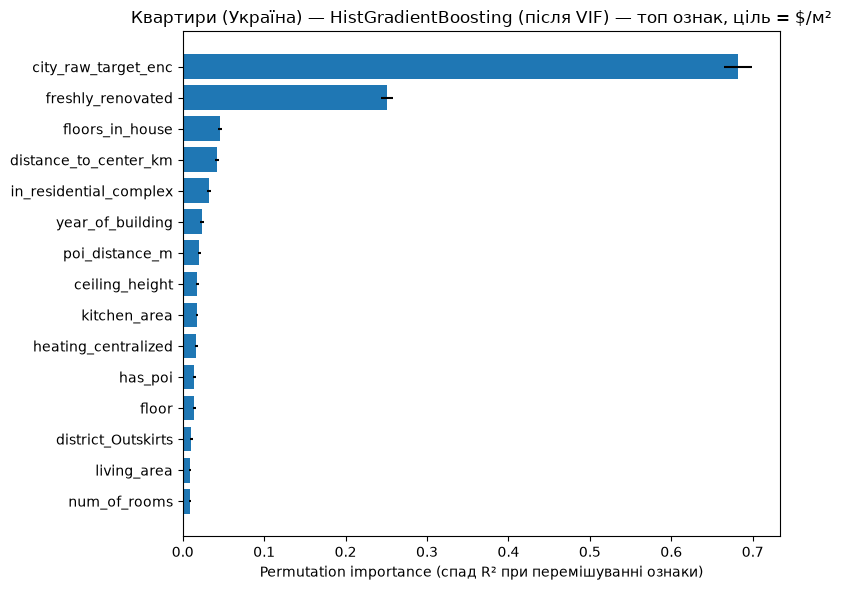

In [8]:
def train_and_compare(df: pd.DataFrame, vif_thresh: float = 10.0):
    X, y, cat_raw = build_feature_frame(df)
    idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)

    X_train, X_test = X.loc[idx_train].copy(), X.loc[idx_test].copy()
    y_train, y_test = y.loc[idx_train], y.loc[idx_test]

    te_mapping, te_global_mean = fit_target_encoding(cat_raw.loc[idx_train], y_train)
    enc_col = f"{CAT_COL}_target_enc"
    X_train[enc_col] = apply_target_encoding(cat_raw.loc[idx_train], te_mapping, te_global_mean).values
    X_test[enc_col] = apply_target_encoding(cat_raw.loc[idx_test], te_mapping, te_global_mean).values

    full_cols = list(X.columns) + [enc_col]

    print("--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---")
    results, fitted = {}, {}
    for name in ["Ridge", "RandomForest", "HistGradientBoosting"]:
        model, _, metrics = fit_variant(name, X_train, X_test, y_train, y_test, full_cols)
        results[name] = metrics
        fitted[name] = model

    results_df = pd.DataFrame(results).T
    print("\n--- Результати на test (повний набір ознак) ---")
    print(results_df)

    best_name = results_df["MAPE_%"].idxmin()
    print(f"\n>>> Найкраща модель: {best_name}")

    print("\n--- VIF-відбір (лише для feature importance, на train) ---")
    kept_cols = prune_by_vif(X_train, thresh=vif_thresh)

    best_model_pruned, X_test_pruned, pruned_metrics = fit_variant(
        best_name, X_train, X_test, y_train, y_test, kept_cols
    )
    print(f"\nR² {best_name}: повний набір ознак = {results_df.loc[best_name, 'R2']:.3f}, "
          f"після VIF-відбору = {pruned_metrics['R2']:.3f}")
    print(f"MAPE_% $/м² після VIF-відбору: {pruned_metrics['MAPE_%']:.1f}%")

    perm = permutation_importance(
        best_model_pruned, X_test_pruned, y_test, n_repeats=20,
        random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
    )
    importance_df = (
        pd.DataFrame({"feature": kept_cols, "importance": perm.importances_mean,
                      "std": perm.importances_std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    top_n = importance_df.head(15)
    plt.figure(figsize=(8, 6))
    plt.barh(top_n["feature"][::-1], top_n["importance"][::-1], xerr=top_n["std"][::-1])
    plt.xlabel("Permutation importance (спад R² при перемішуванні ознаки)")
    plt.title(f"Квартири (Україна) — {best_name} (після VIF) — топ ознак, ціль = $/м²")
    plt.tight_layout()
    plt.show()

    return {
        "results_df": results_df,
        "best_name": best_name,
        "best_model_pruned": best_model_pruned,
        "fixed_params": get_model_params(best_name, best_model_pruned),
        "importance_df": importance_df,
        "kept_cols": kept_cols,
        "enc_col": enc_col,
    }


result = train_and_compare(df)

In [9]:
result["importance_df"].head(15)

,feature,importance,std
0,city_raw_target_enc,0.681886,0.016696
1,freshly_renovated,0.250574,0.007288
2,floors_in_house,0.045526,0.002375
3,distance_to_center_km,0.041996,0.002740
4,in_residential_complex,0.032113,0.002438
5,year_of_building,0.023757,0.001952
6,poi_distance_m,0.020304,0.001716
7,ceiling_height,0.018045,0.001715
8,kitchen_area,0.017755,0.001595
9,heating_centralized,0.016764,0.001821


In [10]:
from sklearn.linear_model import LinearRegression

X, y, cat_raw = build_feature_frame(df)
idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

te_mapping, te_global_mean = fit_target_encoding(cat_raw.loc[idx_train], y_train)
city_only_train = apply_target_encoding(cat_raw.loc[idx_train], te_mapping, te_global_mean).values.reshape(-1, 1)
city_only_test = apply_target_encoding(cat_raw.loc[idx_test], te_mapping, te_global_mean).values.reshape(-1, 1)

baseline = LinearRegression().fit(city_only_train, y_train)
r2_baseline = baseline.score(city_only_test, y_test)

print(f"R² тільки з 'середньою ціною міста': {r2_baseline:.3f}")
print(f"R² повної моделі: {result['results_df'].loc[result['best_name'], 'R2']:.3f}")

R² тільки з 'середньою ціною міста': 0.459
R² повної моделі: 0.787


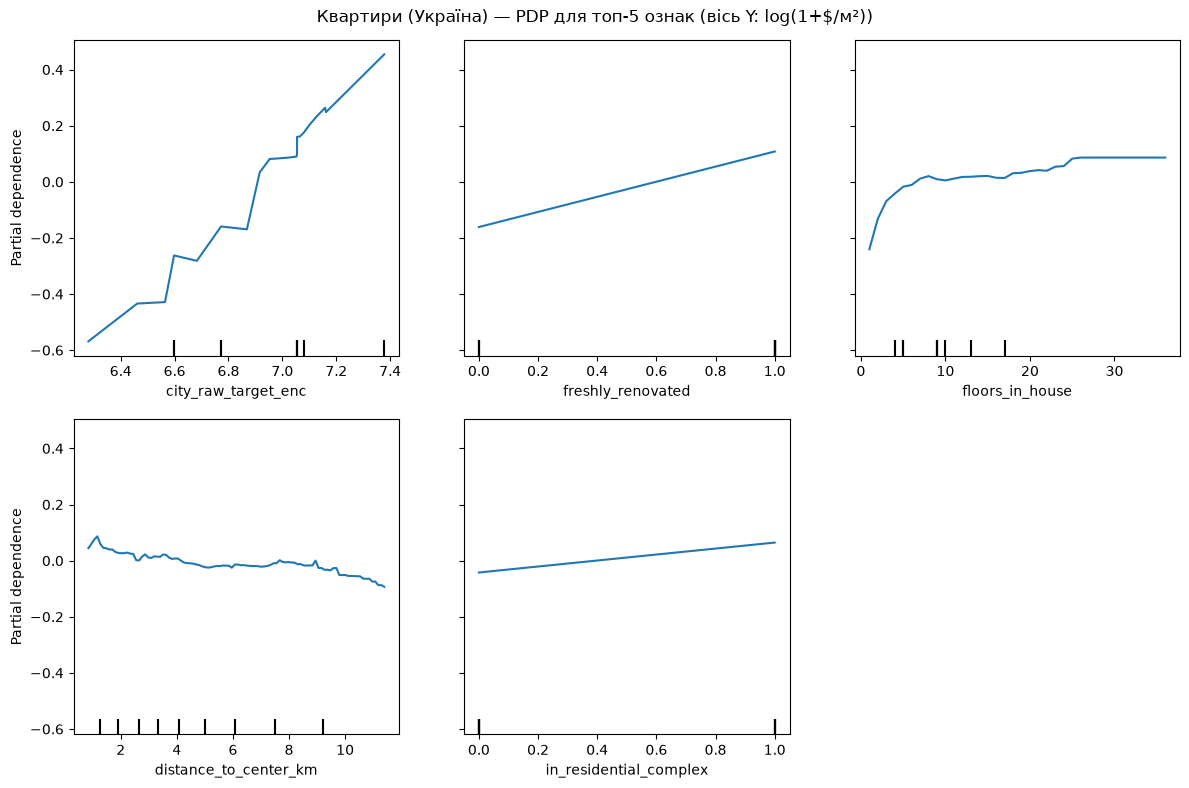

In [11]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.pipeline import make_pipeline

TOP_N_PDP = 5
top_features = result["importance_df"]["feature"].head(TOP_N_PDP).tolist()

X, y, cat_raw = build_feature_frame(df)
idx_train, _ = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
X_train = X.loc[idx_train].copy()
y_train = y.loc[idx_train]

te_mapping, te_global_mean = fit_target_encoding(cat_raw.loc[idx_train], y_train)
X_train[result["enc_col"]] = apply_target_encoding(cat_raw.loc[idx_train], te_mapping, te_global_mean).values

kept_cols = result["kept_cols"]
X_train_kept = X_train[kept_cols].astype(float)

if result["best_name"] == "Ridge":
    scaler_for_pdp = StandardScaler().fit(X_train_kept)
    pdp_estimator = make_pipeline(scaler_for_pdp, result["best_model_pruned"])
else:
    pdp_estimator = result["best_model_pruned"]

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    pdp_estimator, X_train_kept, features=top_features, ax=ax,
)
plt.suptitle(f"Квартири (Україна) — PDP для топ-{TOP_N_PDP} ознак (вісь Y: log(1+$/м²))")
plt.tight_layout()
plt.show()

In [12]:
def cross_validate_best(df: pd.DataFrame, best_name: str, kept_cols: list[str],
                         fixed_params: dict, enc_col: str, n_splits: int = 5):
    X, y, cat_raw = build_feature_frame(df)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []

    for fold_i, (tr_idx, val_idx) in enumerate(kf.split(df.index), start=1):
        idx_tr = df.index[tr_idx]
        idx_val = df.index[val_idx]

        X_tr, X_val = X.loc[idx_tr].copy(), X.loc[idx_val].copy()
        y_tr, y_val = y.loc[idx_tr], y.loc[idx_val]

        te_mapping, te_global_mean = fit_target_encoding(cat_raw.loc[idx_tr], y_tr)
        X_tr[enc_col] = apply_target_encoding(cat_raw.loc[idx_tr], te_mapping, te_global_mean).values
        X_val[enc_col] = apply_target_encoding(cat_raw.loc[idx_val], te_mapping, te_global_mean).values

        cols = [c for c in kept_cols if c in X_tr.columns]
        _, _, metrics = fit_variant(best_name, X_tr, X_val, y_tr, y_val, cols, fixed_params=fixed_params)
        metrics["fold"] = fold_i
        fold_metrics.append(metrics)

    cv_df = pd.DataFrame(fold_metrics).set_index("fold")
    summary = cv_df.agg(["mean", "std"])
    print(cv_df)
    print("\n--- Підсумок по фолдах ---")
    print(summary)
    return cv_df


cv_results = cross_validate_best(
    df, result["best_name"], result["kept_cols"], result["fixed_params"], result["enc_col"],
)

            R2    MAE_$/m2   RMSE_$/m2     MAPE_%
fold                                             
1     0.786346  171.829467  235.503661  16.548489
2     0.773966  172.410348  246.573846  16.624109
3     0.777439  169.707362  233.582288  16.230370
4     0.796004  167.367669  232.755326  16.003133
5     0.779884  175.017051  242.552547  17.269451

--- Підсумок по фолдах ---
            R2    MAE_$/m2   RMSE_$/m2     MAPE_%
mean  0.782728  171.266379  238.193534  16.535110
std   0.008692    2.886336    6.068437   0.480422


In [13]:
def save_production_pipeline(df: pd.DataFrame, best_name: str, kept_cols: list[str],
                             fixed_params: dict, enc_col: str, out_file: str):
    X, y, cat_raw = build_feature_frame(df)
    te_mapping, te_global_mean = fit_target_encoding(cat_raw, y)
    X[enc_col] = apply_target_encoding(cat_raw, te_mapping, te_global_mean).values

    cols = [c for c in kept_cols if c in X.columns]
    X_c = X[cols]

    scaler = None
    if best_name == "Ridge":
        scaler = StandardScaler().fit(X_c)
        model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(scaler.transform(X_c), y)
    elif best_name == "RandomForest":
        model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_c, y)
    else:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(X_c, y)

    artifact = {
        "model_name": best_name,
        "model": model,
        "scaler": scaler,
        "feature_cols": cols,
        "cat_col": CAT_COL,
        "cat_prefix": CAT_PREFIX,
        "target_encoding_mapping": te_mapping,
        "target_encoding_global_mean": te_global_mean,
        "target_enc_col": enc_col,
    }
    joblib.dump(artifact, out_file)
    print(f"Збережено: {out_file}")
    return artifact


def predict_new_object(artifact: dict, new_row: dict) -> float:
    """new_row — dict з сирими значеннями ознак (як у df ДО one-hot/target
    encoding), включно з CAT_COL (напр. 'district_raw'). Повертає
    прогнозовану ціну за м² в $."""
    row = pd.Series(new_row)
    cat_value = row.get(artifact["cat_col"], None)
    mapping = artifact["target_encoding_mapping"]
    row[artifact["target_enc_col"]] = (
        mapping.get(cat_value, artifact["target_encoding_global_mean"])
        if cat_value in mapping.index else artifact["target_encoding_global_mean"]
    )

    X_new = pd.DataFrame([row])[artifact["feature_cols"]].astype(float)
    if artifact["scaler"] is not None:
        X_new = artifact["scaler"].transform(X_new)

    pred_log = artifact["model"].predict(X_new)[0]
    return float(np.expm1(pred_log))


artifact = save_production_pipeline(
    df, result["best_name"], result["kept_cols"], result["fixed_params"], result["enc_col"],
    out_file="flats_ukraine_model_pipeline.joblib",
)

Збережено: flats_ukraine_model_pipeline.joblib
